<a href="https://colab.research.google.com/github/sj2609/Introduction-to-Computational-Statistics-and-Statistical-Learning/blob/main/CSSL_07_Regularization_and_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import zipfile

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV

!pip install ISLP
from ISLP import load_data

# Utility functions

In [2]:
# Compute RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Load data

In [3]:
df = load_data('Hitters')

Now lets take a look at the data

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


# Preprocessing
We need to find if there are missing values in the dataset and figure out a way to deal with them.

In [5]:
rows_with_na = df[df.isna().any(axis=1)] # checking if any NA
print("\nRows containing NAs:")
rows_with_na


Rows containing NAs:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
15,183,39,3,20,15,11,3,201,42,3,20,16,11,A,W,118,0,0,NaN,A
18,407,104,6,57,43,65,12,5233,1478,100,643,658,653,A,W,912,88,9,NaN,A
22,22,10,1,4,2,1,6,84,26,2,9,9,3,A,W,812,84,11,NaN,A
30,313,84,9,42,30,39,17,6890,1833,224,1033,864,1087,A,W,127,221,7,NaN,A
32,517,141,27,70,87,52,9,3571,994,215,545,652,337,N,W,1378,102,8,NaN,N
36,161,36,0,19,10,17,4,1053,244,3,156,86,107,A,E,70,149,12,NaN,A
38,346,98,5,31,53,30,16,5913,1615,235,784,901,560,A,E,0,0,0,NaN,A
39,241,61,1,34,12,14,1,241,61,1,34,12,14,N,W,166,172,10,NaN,N
41,216,54,0,21,18,15,18,7318,1926,46,796,627,483,N,W,103,84,5,NaN,N


Let's drop the rows with NaN values and split the dataset into train and test.

In [7]:
df = df.dropna().reset_index(drop=True)
target = "Salary"      # trying to predict
X = df.drop(columns=[target])   # everything except salary is stored in X
y = df[target]
print(X.shape, y.shape)

# First split: train+val vs test (80% / 20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

# Second split: train vs validation (75% / 25% of remaining 80%)    #still add 20 observations to send
# This gives: 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=20
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

# is.na function used here is from pandas

(263, 19) (263,)
Train size: 157
Validation size: 53
Test size: 53


Now we need to transform the categorical values into numerical values and also scale all the features so that they roughly lie within the same range. If some features are represented using large numbers while others are represented in small numbers, it can skew the error calculcations, similar to what happened when we did polynomial regression.

In [ ]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()     # columns which have numerical data
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()   # columns which have categorcial data

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols), # Scales columns containing numerical data using (x-mu)/sigma so that the values have mean 0 and standard deviation 1
        ("cat", OneHotEncoder(drop="first"), categorical_cols) # Encodes categorical values using one hot encoding
    ]
)


In [8]:
# If you want to understand how the OneHotEncoder works, uncomment the below lines of code and try it out
X_1hot = [["East"], ["West"], ["Central"]]

enc = OneHotEncoder(drop="first", sparse_output=False) # Note- The encoder sorts the list of unique categories before encoding alphabetically,drops central here
encoded = enc.fit_transform(X_1hot)

print(encoded)

[[1. 0.]
 [0. 1.]
 [0. 0.]]


# Linear regression using OLS

In [18]:
# OLS Model
ols_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# 2) Fit on training data
ols_model.fit(X_train_val, y_train_val)

# 3) Predictions
y_train_pred = ols_model.predict(X_train_val)
y_test_pred  = ols_model.predict(X_test)


ols_test_rmse = rmse(y_test,y_test_pred)

print("OLS Performance:")
print("Train RMSE:", rmse(y_train, y_train_pred))
print("Test RMSE:", rmse(y_test, y_test_pred))

NameError: name 'preprocess' is not defined

In [19]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()     # columns which have numerical data
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()   # columns which have categorcial data

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols), # Scales columns containing numerical data using (x-mu)/sigma so that the values have mean 0 and standard deviation 1
        ("cat", OneHotEncoder(drop="first"), categorical_cols) # Encodes categorical values using one hot encoding
    ]
)


Best lambda for ridge: 48.62601580065353
Best Validation RMSE for ridge: 347.5943722166363
Best lambda for lasso: 2.9836472402833403
Best Validation RMSE for lasso: 350.19440206990436


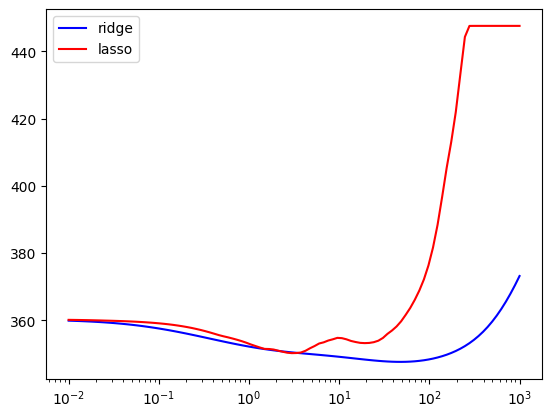

In [24]:
# Define lambdas grid
lambdas = np.logspace(-2, 3, 100)

# 5-fold CV
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

ridge_val_rmse = np.full((num_folds, len(lambdas)), np.inf)   # number of rows is num_folds and the no of lambdas is the no of columns, why are we using np.inf?
lasso_val_rmse = np.full((num_folds, len(lambdas)), np.inf)


for l_ind, l in enumerate(lambdas):
  fold = 0

  for train_idx, val_idx in kf.split(X_train_val):

    X_train_fold = X_train_val.iloc[train_idx]
    y_train_fold = y_train_val.iloc[train_idx]
    X_val_fold   = X_train_val.iloc[val_idx]
    y_val_fold   = y_train_val.iloc[val_idx]

    # Pipeline: preprocessing + Ridge
    ridge_model = Pipeline([
            ("preprocess", preprocess),
            ("ridge", Ridge(alpha=l, max_iter=10000))
        ])

    ridge_model.fit(X_train_fold, y_train_fold)
    ridge_preds = ridge_model.predict(X_val_fold)

    ridge_val_rmse[fold, l_ind] = rmse(y_val_fold, ridge_preds)


    # Pipeline: preprocessing + Lasso
    lasso_model = Pipeline([
            ("preprocess", preprocess),
            ("lasso", Lasso(alpha=l, max_iter=10000))    # l is the value we are supplying
        ])

    lasso_model.fit(X_train_fold, y_train_fold)
    lasso_preds = lasso_model.predict(X_val_fold)

    lasso_val_rmse[fold, l_ind] = rmse(y_val_fold, lasso_preds) # Corrected line

    fold += 1

ridge_mean_rmse = np.mean(ridge_val_rmse, axis=0)
lasso_mean_rmse = np.mean(lasso_val_rmse, axis=0)

# Find best lambda for lasso
ridge_best_lambda = lambdas[np.argmin(ridge_mean_rmse)]
print("Best lambda for ridge:", ridge_best_lambda)
print("Best Validation RMSE for ridge:", min(ridge_mean_rmse))

# Find best lambda for lasso
lasso_best_lambda = lambdas[np.argmin(lasso_mean_rmse)]
print("Best lambda for lasso:", lasso_best_lambda)
print("Best Validation RMSE for lasso:", min(lasso_mean_rmse))


# Plot the lambdas vs mean_rmse for ridge and lasso
plt.figure()
plt.plot(lambdas, ridge_mean_rmse, c="b", label="ridge")
plt.plot(lambdas, lasso_mean_rmse, c="r", label="lasso")

plt.xscale('log')
plt.legend()

# Fit the final model
Now that we have the best lambda values, we can try to fit the whole train+val dataset using these values.

In [1]:
ridge_final_model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=ridge_best_lambda))
])

ridge_final_model.fit(X_train_val, y_train_val)   # in case of lasso, if using less no of itertions might not converghe why

ridge_test_preds = ridge_final_model.predict(X_test)

lasso_final_model = Pipeline([
    ("preprocess", preprocess),
    ("lasso", Lasso(alpha=lasso_best_lambda))
])

lasso_final_model.fit(X_train_val, y_train_val)

lasso_test_preds = lasso_final_model.predict(X_test)

#print("Test RMSE for OLS:", ols_test_rmse)
print("Test RMSE for Ridge Regression with cross validation:", rmse(y_test, ridge_test_preds))
print("Test RMSE for Lasso Regression with cross validation:", rmse(y_test, lasso_test_preds))


NameError: name 'Pipeline' is not defined

ridge regression is seeming to do slightly better than OLS